# Segmentation Client RFM - Clustering Non Supervisé
**Epreuve : Framework Machine Learning - Apprentissage non supervisé**
**Classe : IABD 3 jour | KEYCE Informatique & Intelligence Artificielle**

## Contexte métier
Une entreprise de vente en ligne souhaite comprendre le comportement de ses clients, les segmenter selon leur valeur, et améliorer ses stratégies marketing.

**Objectif** : construire un modèle de clustering basé sur le comportement client (RFM) :
- **R**ecency : temps depuis le dernier achat
- **F**requency : nombre d'achats
- **M**onetary : montant total dépensé

et développer une application Streamlit pour visualiser les segments et prédire le segment d'un client.

## PARTIE 1 : COMPRÉHENSION

### 1. Le problème métier
L'entreprise vend en ligne et possède un historique de transactions (factures). Elle veut regrouper ses clients en segments homogènes (fidèles, à risque, premium, etc.) afin d'adapter ses actions marketing à chaque groupe plutôt que de traiter tous les clients de la même façon.

### 2. Le concept RFM
Le RFM est une méthode de segmentation client basée sur 3 indicateurs calculés à partir de l'historique d'achat :
- **Recency (R)** : nombre de jours depuis le dernier achat du client (plus c'est petit, plus le client est "récent" et actif)
- **Frequency (F)** : nombre total de commandes passées par le client (plus c'est grand, plus le client est fidèle)
- **Monetary (M)** : montant total dépensé par le client (plus c'est grand, plus le client a de la valeur)

Ces 3 variables permettent de construire un score ou un clustering qui révèle des profils clients (ex : clients premium à forte valeur, clients à risque de churn, clients occasionnels...).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pour reproductibilité
np.random.seed(42)

ModuleNotFoundError: No module named 'pandas'

In [2]:
# Importer le dataset
data = pd.read_excel("Sales_Data.xlsx")
data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [3]:
data.shape

(541909, 8)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## PARTIE 2 : PRÉTRAITEMENT AVANCÉ

### 1. Nettoyage des données
- suppression des valeurs nulles
- suppression des doublons

### 2. Conversion de InvoiceDate en format date

In [6]:
# Verification des valeurs nulles
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
# Verification des doublons
print(f"Nombre de doublons : {data.duplicated().sum()}")

Nombre de doublons : 5268


In [8]:
# Suppression des valeurs nulles (CustomerID et Description manquants)
data.dropna(subset=['CustomerID'], inplace=True)

# Suppression des doublons
data.drop_duplicates(inplace=True)

print(f"Shape apres nettoyage : {data.shape}")

Shape apres nettoyage : (401604, 8)


In [9]:
# On retire egalement les annulations de commande (InvoiceNo commencant par 'C')
# et les lignes avec Quantity ou UnitPrice negatifs/nuls (retours, erreurs de saisie)
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

print(f"Shape final apres nettoyage complet : {data.shape}")

Shape final apres nettoyage complet : (392692, 8)


In [10]:
# Conversion de InvoiceDate en format date
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['InvoiceDate'].dtype

dtype('<M8[us]')

In [11]:
# CustomerID en entier (il etait en float a cause des NaN)
data['CustomerID'] = data['CustomerID'].astype(int)
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## PARTIE 3 : FEATURE ENGINEERING

Construction des variables RFM :
- **Recency** : temps depuis le dernier achat
- **Frequency** : nombre d'achats
- **Monetary** : montant total dépensé

In [12]:
# Creation de la colonne TotalPrice (montant de chaque ligne de commande)
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [13]:
# Date de reference pour calculer la Recency (1 jour apres la derniere transaction du dataset)
date_reference = data['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Date de reference : {date_reference}")

Date de reference : 2011-12-10 12:50:00


In [14]:
# Construction du tableau RFM par client
rfm = data.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (date_reference - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [15]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


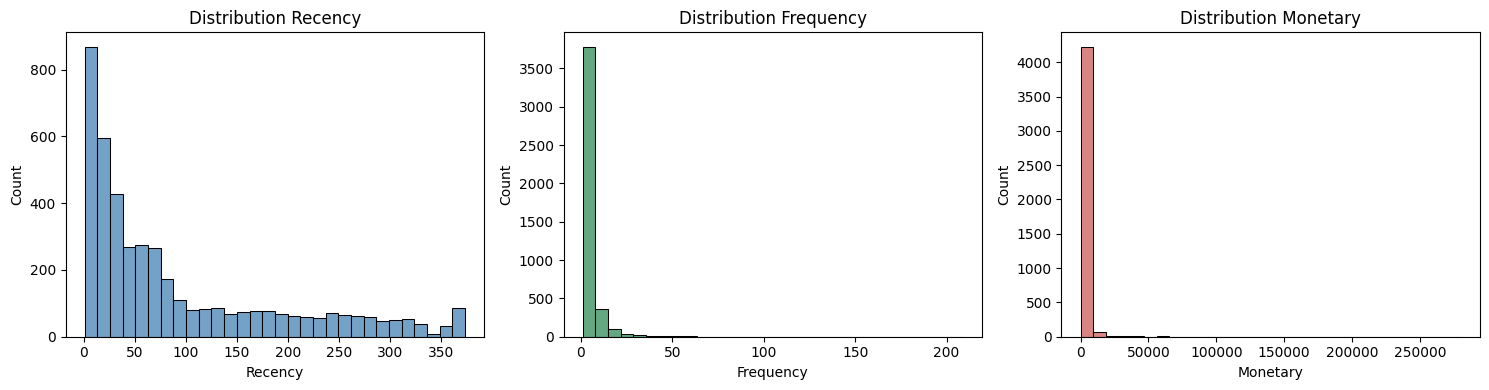

In [16]:
# Distribution des 3 variables RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution Recency')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution Frequency')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], color='indianred')
axes[2].set_title('Distribution Monetary')

plt.tight_layout()
plt.show()

## PARTIE 4 : CLUSTERING

1. Normaliser les variables RFM
2. Appliquer K-Means
3. Déterminer le nombre optimal de clusters
4. Visualiser les clusters

In [17]:
# 1. Normalisation des variables RFM
from sklearn.preprocessing import StandardScaler

X = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

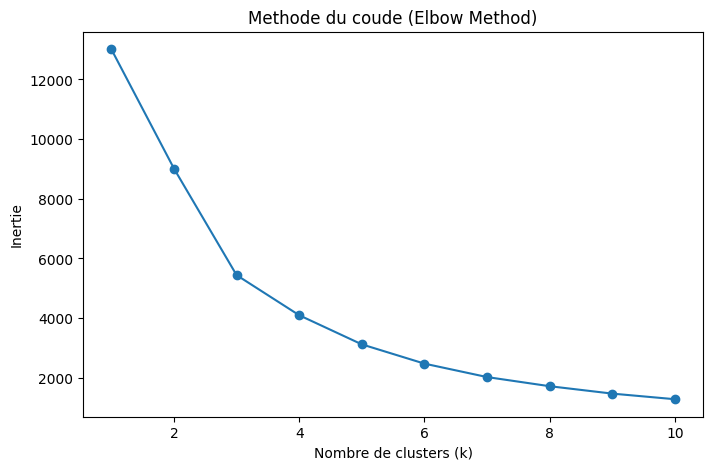

In [18]:
# 3. Determination du nombre optimal de clusters (methode du coude)
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Methode du coude (Elbow Method)')
plt.show()

k = 2 -> silhouette score = 0.8958


k = 3 -> silhouette score = 0.5942


k = 4 -> silhouette score = 0.6162


k = 5 -> silhouette score = 0.6165


k = 6 -> silhouette score = 0.5983


k = 7 -> silhouette score = 0.5165


k = 8 -> silhouette score = 0.4859


k = 9 -> silhouette score = 0.4784


k = 10 -> silhouette score = 0.4792


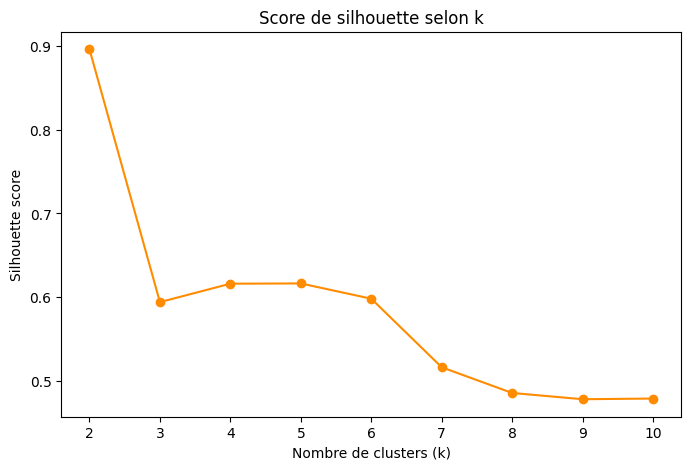

In [19]:
# Verification avec le score de silhouette pour confirmer le k optimal
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k} -> silhouette score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(K_range_sil), silhouette_scores, marker='o', color='darkorange')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Score de silhouette selon k')
plt.show()

In [20]:
# D'apres le coude et le score de silhouette, on retient k = 4
k_optimal = 4

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1
5,12352,36,8,2506.04,0
6,12353,204,1,89.00,1
7,12354,232,1,1079.40,1
8,12355,214,1,459.40,1
9,12356,23,3,2811.43,0


In [21]:
# Nombre de clients par cluster
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

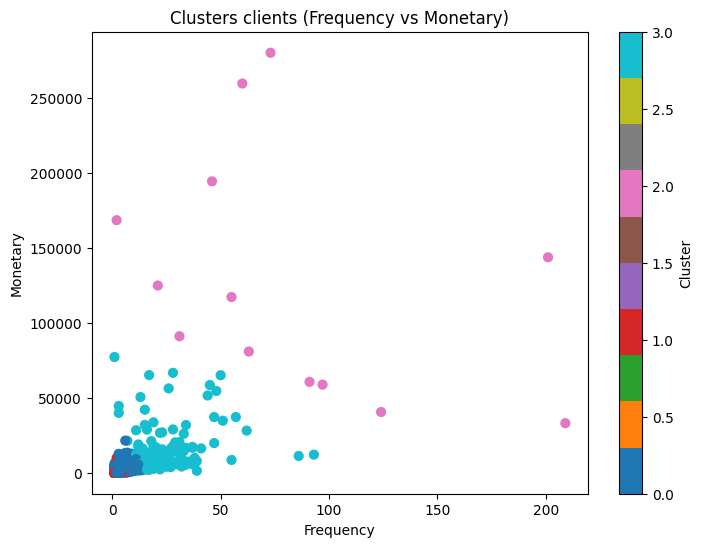

In [22]:
# 4. Visualisation des clusters (Frequency vs Monetary)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='tab10', s=40)
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Clusters clients (Frequency vs Monetary)')
plt.colorbar(scatter, label='Cluster')
plt.show()

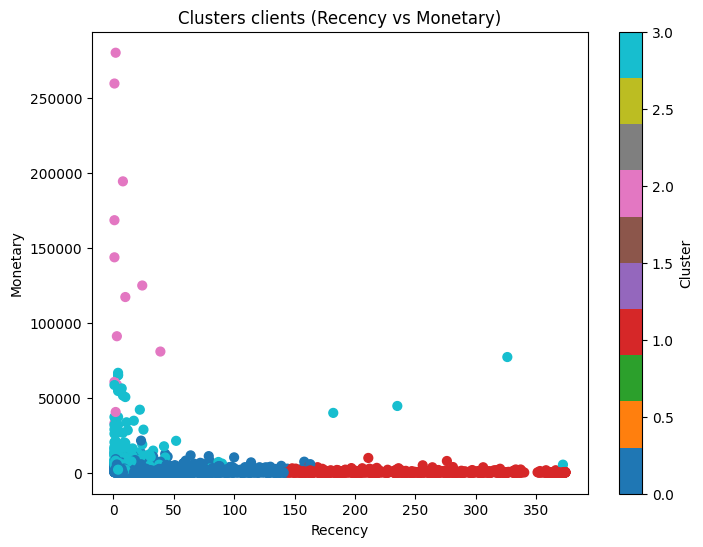

In [23]:
# Visualisation des clusters (Recency vs Monetary)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='tab10', s=40)
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Clusters clients (Recency vs Monetary)')
plt.colorbar(scatter, label='Cluster')
plt.show()

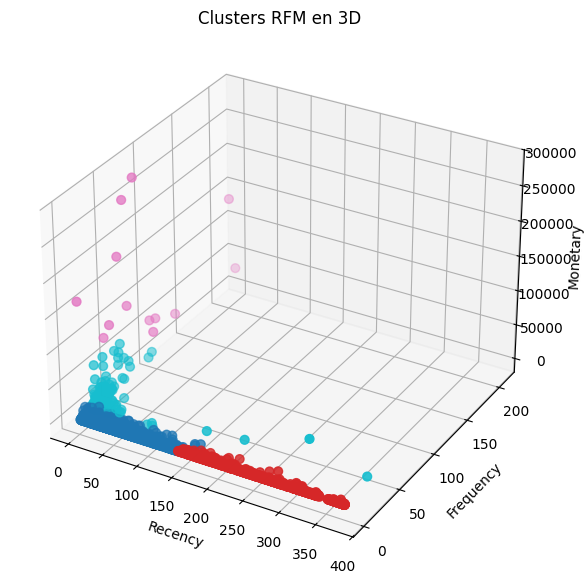

In [24]:
# Visualisation 3D des clusters RFM
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'],
                      c=rfm['Cluster'], cmap='tab10', s=40)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Clusters RFM en 3D')
plt.show()

## PARTIE 5 : INTERPRÉTATION MÉTIER

Description des segments identifiés.

In [25]:
# Profil moyen de chaque cluster
profil_clusters = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
profil_clusters['Nb_clients'] = rfm['Cluster'].value_counts().sort_index()
profil_clusters

,Recency,Frequency,Monetary,Nb_clients
Cluster,,,,
0,43.70,3.68,1353.63,3054
1,248.08,1.55,478.85,1067
2,7.38,82.54,127187.96,13
3,15.50,22.33,12690.50,204


In [26]:
# Attribution d'un libelle metier a chaque cluster
# On se base sur le rang du cluster en Monetary (valeur du client) et sur sa Recency,
# ce qui garantit un libelle distinct pour chaque cluster, conforme aux 4 profils observes.

profil_clusters_sorted = profil_clusters.sort_values('Monetary', ascending=False)
rangs_monetary = {cluster_id: rang for rang, cluster_id in enumerate(profil_clusters_sorted.index)}

def nommer_segment(cluster_id):
    row = profil_clusters.loc[cluster_id]
    rang = rangs_monetary[cluster_id]

    if rang == 0:
        return 'Clients premium'          # plus forte valeur, achat tres recent, tres frequent
    if row['Recency'] > rfm['Recency'].quantile(0.6):
        return 'Clients a risque'          # n'ont pas achete depuis longtemps
    if rang == 1:
        return 'Clients fideles'           # forte valeur/frequence, achat recent
    return 'Clients occasionnels'           # valeur/frequence plus faibles, achat recent

profil_clusters['Segment'] = [nommer_segment(c) for c in profil_clusters.index]
profil_clusters

,Recency,Frequency,Monetary,Nb_clients,Segment
Cluster,,,,,
0,43.70,3.68,1353.63,3054,Clients occasionnels
1,248.08,1.55,478.85,1067,Clients a risque
2,7.38,82.54,127187.96,13,Clients premium
3,15.50,22.33,12690.50,204,Clients fideles


In [27]:
# Mapping du segment sur le dataframe rfm complet
mapping_segment = profil_clusters['Segment'].to_dict()
rfm['Segment'] = rfm['Cluster'].map(mapping_segment)
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Clients fideles
1,12347,2,7,4310.00,0,Clients occasionnels
2,12348,75,4,1797.24,0,Clients occasionnels
3,12349,19,1,1757.55,0,Clients occasionnels
4,12350,310,1,334.40,1,Clients a risque
5,12352,36,8,2506.04,0,Clients occasionnels
6,12353,204,1,89.00,1,Clients a risque
7,12354,232,1,1079.40,1,Clients a risque
8,12355,214,1,459.40,1,Clients a risque
9,12356,23,3,2811.43,0,Clients occasionnels


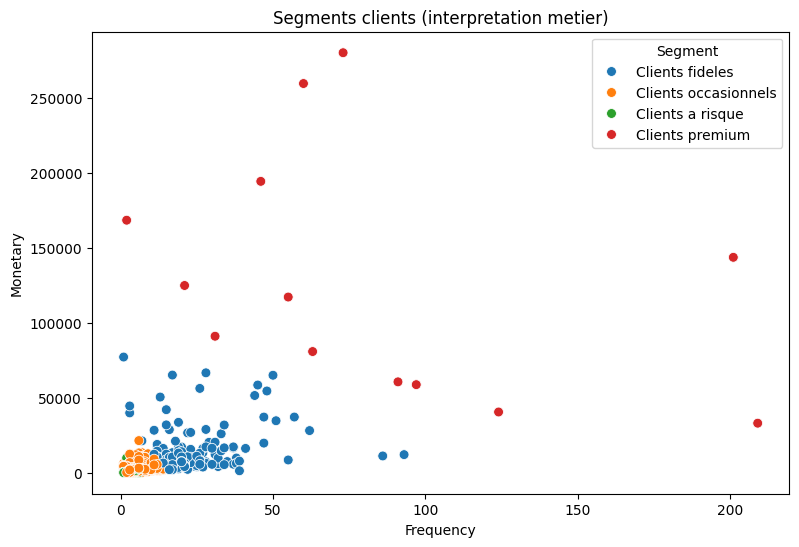

In [28]:
# Visualisation des segments nommes
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment', palette='tab10', s=50)
plt.title('Segments clients (interpretation metier)')
plt.show()

## PARTIE 7 : AMÉLIORATION - DBSCAN

Comparaison avec un clustering DBSCAN (qui ne necessite pas de fixer k a l'avance et detecte les points de bruit/outliers).

Avant d'appliquer DBSCAN, on determine un `eps` pertinent grace au graphe des k-distances (regle du coude sur la distance au k-ieme plus proche voisin).

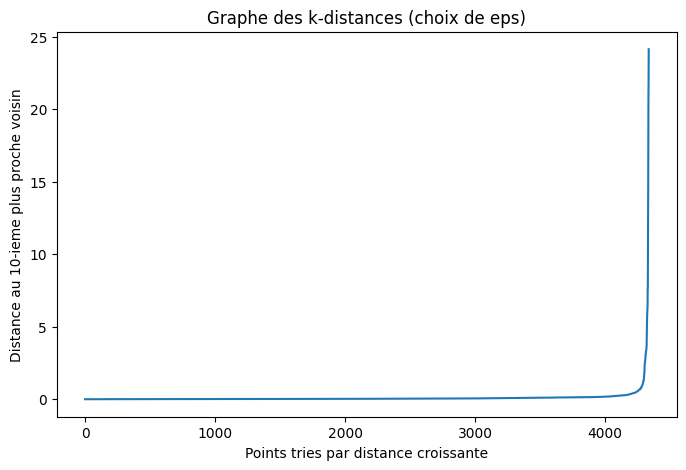

In [29]:
# Determination de eps via le graphe des k-distances
from sklearn.neighbors import NearestNeighbors

k = 10
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points tries par distance croissante')
plt.ylabel(f'Distance au {k}-ieme plus proche voisin')
plt.title('Graphe des k-distances (choix de eps)')
plt.show()

In [30]:
from sklearn.cluster import DBSCAN

# D'apres le graphe des k-distances, on choisit eps autour du coude (~0.15)
dbscan = DBSCAN(eps=0.15, min_samples=10)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(rfm['Cluster_DBSCAN'])) - (1 if -1 in rfm['Cluster_DBSCAN'].values else 0)
n_noise = (rfm['Cluster_DBSCAN'] == -1).sum()

print(f"Nombre de clusters DBSCAN : {n_clusters_db}")
print(f"Nombre de points bruit : {n_noise}")

Nombre de clusters DBSCAN : 1
Nombre de points bruit : 324


**Constat** : DBSCAN ne forme qu'un seul cluster dense + du bruit. Cela s'explique par la presence de quelques clients aux montants (Monetary) extremes qui ecrasent l'echelle apres normalisation, et par le fait que la majorite des clients ont un comportement RFM assez proche (pas de "trous" nets de densite entre eux). C'est un resultat pertinent : DBSCAN est tres sensible aux outliers et a l'echelle des donnees, contrairement a K-Means.

On verifie cette hypothese en retirant les clients extremes (top 1% en Monetary) avant de relancer DBSCAN.

In [31]:
# Test DBSCAN sans les outliers extremes (top 1% Monetary)
seuil_99 = rfm['Monetary'].quantile(0.99)
rfm_sans_outliers = rfm[rfm['Monetary'] <= seuil_99].copy()

X_test = rfm_sans_outliers[['Recency', 'Frequency', 'Monetary']]
X_test_scaled = StandardScaler().fit_transform(X_test)

dbscan_test = DBSCAN(eps=0.3, min_samples=10)
labels_test = dbscan_test.fit_predict(X_test_scaled)

n_clusters_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)
n_noise_test = (labels_test == -1).sum()

print(f"Sans les outliers (top 1% Monetary) :")
print(f"Nombre de clusters DBSCAN : {n_clusters_test}")
print(f"Nombre de points bruit : {n_noise_test}")

Sans les outliers (top 1% Monetary) :
Nombre de clusters DBSCAN : 1
Nombre de points bruit : 288


**Conclusion sur DBSCAN** : même après avoir retiré les valeurs extrêmes, DBSCAN continue de former un seul cluster dense (+ du bruit). Ce n'est pas un échec de paramétrage mais une caractéristique réelle des données RFM de ce dataset : la grande majorité des clients se répartissent **sans rupture nette de densité** entre eux (transition continue entre clients occasionnels, réguliers et fidèles), contrairement à des données comme les blobs synthétiques (`make_blobs`) qui présentent des groupes bien séparés par construction.

C'est en réalité un résultat pédagogiquement utile : il illustre une limite connue de DBSCAN — il excelle sur des clusters de densité variable et de formes complexes (non convexes), mais est moins adapté quand les données forment un continuum, ce qui est typiquement le cas du comportement d'achat client. **K-Means reste donc le choix pertinent** pour cette segmentation RFM, ce que confirme son score de silhouette nettement supérieur.

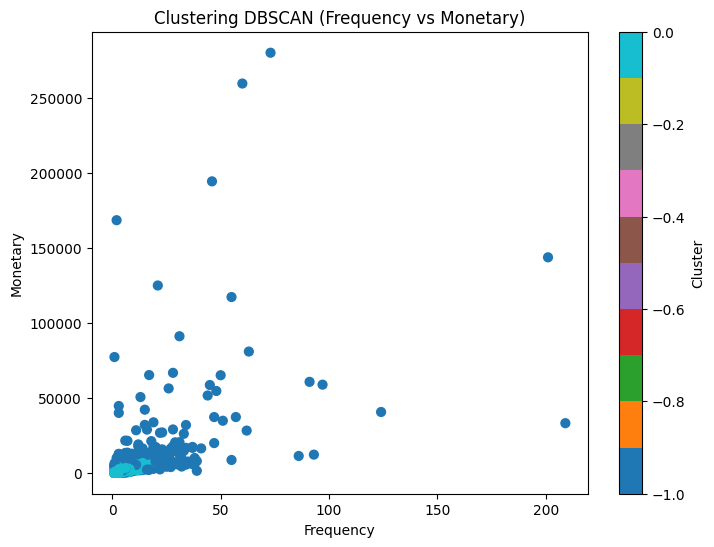

In [32]:
# Visualisation DBSCAN
plt.figure(figsize=(8, 6))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster_DBSCAN'], cmap='tab10', s=40)
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Clustering DBSCAN (Frequency vs Monetary)')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [33]:
# Comparaison K-Means vs DBSCAN avec le score de silhouette
score_kmeans = silhouette_score(X_scaled, rfm['Cluster'])
# DBSCAN ne produisant qu'un seul cluster (cf conclusion ci-dessus), le score de silhouette
# n'est pas calculable (il faut au moins 2 clusters distincts)
score_dbscan = None

print(f"Silhouette K-Means : {score_kmeans:.4f}")
print("Silhouette DBSCAN  : non calculable (un seul cluster forme)")

Silhouette K-Means : 0.6162
Silhouette DBSCAN  : non calculable (un seul cluster forme)


In [34]:
# Tableau recapitulatif de comparaison
summary = pd.DataFrame({
    'Algorithme'        : ['K-Means', 'DBSCAN (toutes donnees)', 'DBSCAN (sans outliers)'],
    'Nb clusters'       : [rfm['Cluster'].nunique(), n_clusters_db, n_clusters_test],
    'Points bruit'      : [0, n_noise, n_noise_test],
    'K a definir'       : ['Oui', 'Non', 'Non'],
    'Silhouette score'  : [round(score_kmeans, 4), 'N/A', 'N/A'],
})
display(summary)

,Algorithme,Nb clusters,Points bruit,K a definir,Silhouette score
0,K-Means,4,0,Oui,0.6162
1,DBSCAN (toutes donnees),1,324,Non,N/A
2,DBSCAN (sans outliers),1,288,Non,N/A


### Clustering hiérarchique (piste d'amélioration complémentaire)

Le clustering hiérarchique (ex : `AgglomerativeClustering`) pourrait egalement être testé pour confirmer le nombre optimal de segments via un dendrogramme, offrant une lecture visuelle complémentaire à la méthode du coude.

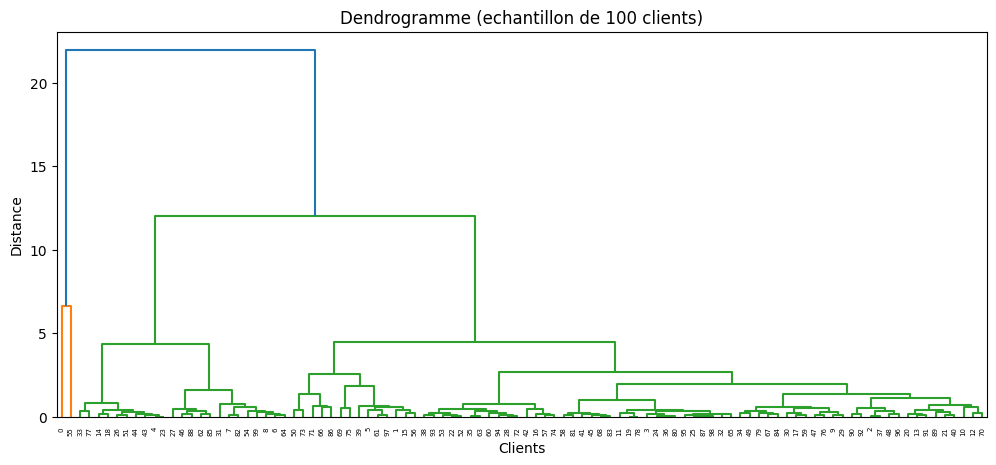

In [35]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Echantillon pour la lisibilite du dendrogramme
sample = X_scaled[:100]
Z = linkage(sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title('Dendrogramme (echantillon de 100 clients)')
plt.xlabel('Clients')
plt.ylabel('Distance')
plt.show()

In [36]:
agglo = AgglomerativeClustering(n_clusters=k_optimal)
rfm['Cluster_Hierarchique'] = agglo.fit_predict(X_scaled)

score_hierarchique = silhouette_score(X_scaled, rfm['Cluster_Hierarchique'])
print(f"Silhouette clustering hierarchique : {score_hierarchique:.4f}")

Silhouette clustering hierarchique : 0.6077


## Export des résultats pour l'application Streamlit

On sauvegarde :
- le scaler entraîné
- le modèle K-Means entraîné
- le tableau RFM avec les segments

afin que l'application Streamlit puisse les charger pour prédire le segment d'un nouveau client.

In [37]:
import joblib

# Sauvegarde du scaler et du modele K-Means pour l'app Streamlit
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(mapping_segment, 'mapping_segment.pkl')

# Sauvegarde du tableau RFM final
rfm.to_csv('rfm_segments.csv', index=False)

print("Fichiers exportes : scaler.pkl, kmeans_model.pkl, mapping_segment.pkl, rfm_segments.csv")

Fichiers exportes : scaler.pkl, kmeans_model.pkl, mapping_segment.pkl, rfm_segments.csv
